In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df=pd.read_csv('house_prices.csv')
pd.set_option('display.max_columns',None)

In [8]:
df.sample(5)

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
19381,868000905,20140708T000000,950000.0,3,2.50,3480,7800,1.0,N,0,Good,7,1750,1730,1941,1998,98177,47.7047,-122.378,3010,9918
19663,1442880510,20140530T000000,499431.0,4,2.75,2620,6019,2.0,N,0,Average,8,2620,0,2013,0,98045,47.4840,-121.771,2790,6716
662,1062100116,20150121T000000,475000.0,3,2.50,1640,5097,2.0,N,0,Average,7,1640,0,1969,0,98155,47.7522,-122.278,1880,6000
20301,1085623730,20141129T000000,498445.0,4,2.50,3216,5902,2.0,N,0,Average,9,3216,0,2014,0,98030,47.3425,-122.179,2815,4916
4850,6705120280,20150331T000000,428000.0,2,2.50,1414,1960,2.0,N,0,Average,8,1414,0,1986,0,98006,47.5423,-122.189,1414,2511


In [9]:
df['date']=df['date'].str[0:8]

In [10]:
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013,221900.0,3,1.00,1180,5650,1.0,N,0,Average,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209,538000.0,3,2.25,2570,7242,2.0,N,0,Average,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225,180000.0,2,1.00,770,10000,1.0,N,0,Average,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209,604000.0,4,3.00,1960,5000,1.0,N,0,Very Good,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218,510000.0,3,2.00,1680,8080,1.0,N,0,Average,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  object 
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  object 
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

In [12]:
df['date']=pd.to_datetime(df['date'])

In [13]:
df.drop(['date','id'],axis=1,inplace=True)

In [14]:
df.corr(numeric_only=True)['price'].sort_values(ascending=False)

price            1.000000
sqft_living      0.702035
grade            0.667434
sqft_above       0.605567
sqft_living15    0.585379
bathrooms        0.525138
view             0.397293
sqft_basement    0.323816
bedrooms         0.308350
lat              0.307003
floors           0.256794
yr_renovated     0.126434
sqft_lot         0.089661
sqft_lot15       0.082447
yr_built         0.054012
long             0.021626
zipcode         -0.053203
Name: price, dtype: float64

In [15]:
df.isna().sum()

price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

In [16]:
df.duplicated().sum()

np.int64(5)

In [17]:
df.drop_duplicates(inplace=True)

<Axes: xlabel='bathrooms', ylabel='price'>

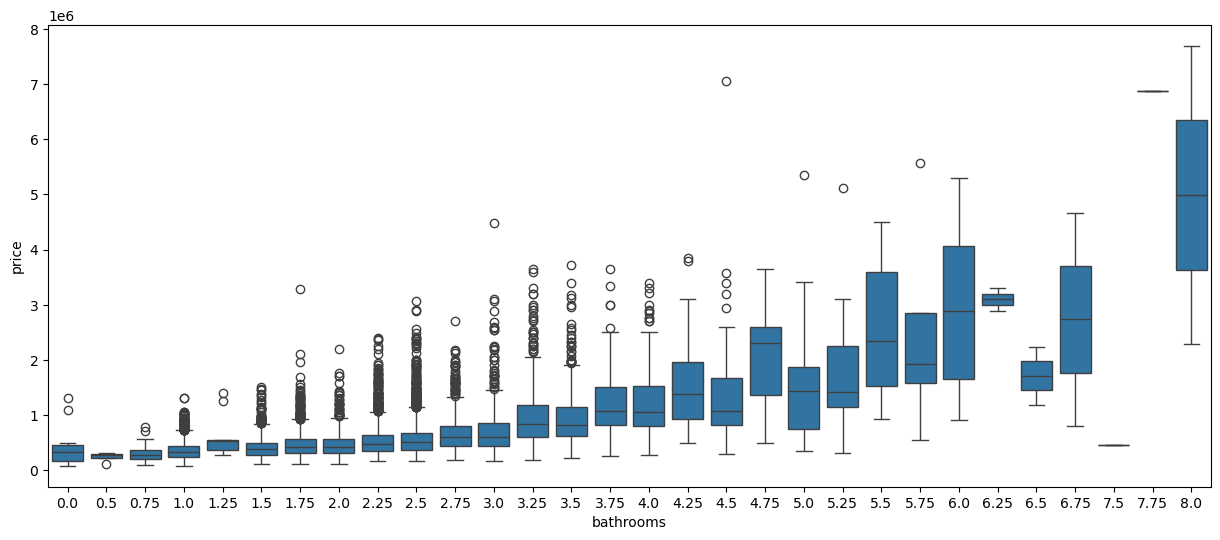

In [18]:
plt.figure(figsize=(15,6))
sns.boxplot(x='bathrooms',y='price',data=df)

In [19]:
df.corr(numeric_only=True)['price']

price            1.000000
bedrooms         0.308326
bathrooms        0.525146
sqft_living      0.702035
sqft_lot         0.089652
floors           0.256893
view             0.397409
grade            0.667541
sqft_above       0.605559
sqft_basement    0.323839
yr_built         0.054062
yr_renovated     0.126489
zipcode         -0.053179
lat              0.307002
long             0.021587
sqft_living15    0.585378
sqft_lot15       0.082435
Name: price, dtype: float64

<Axes: >

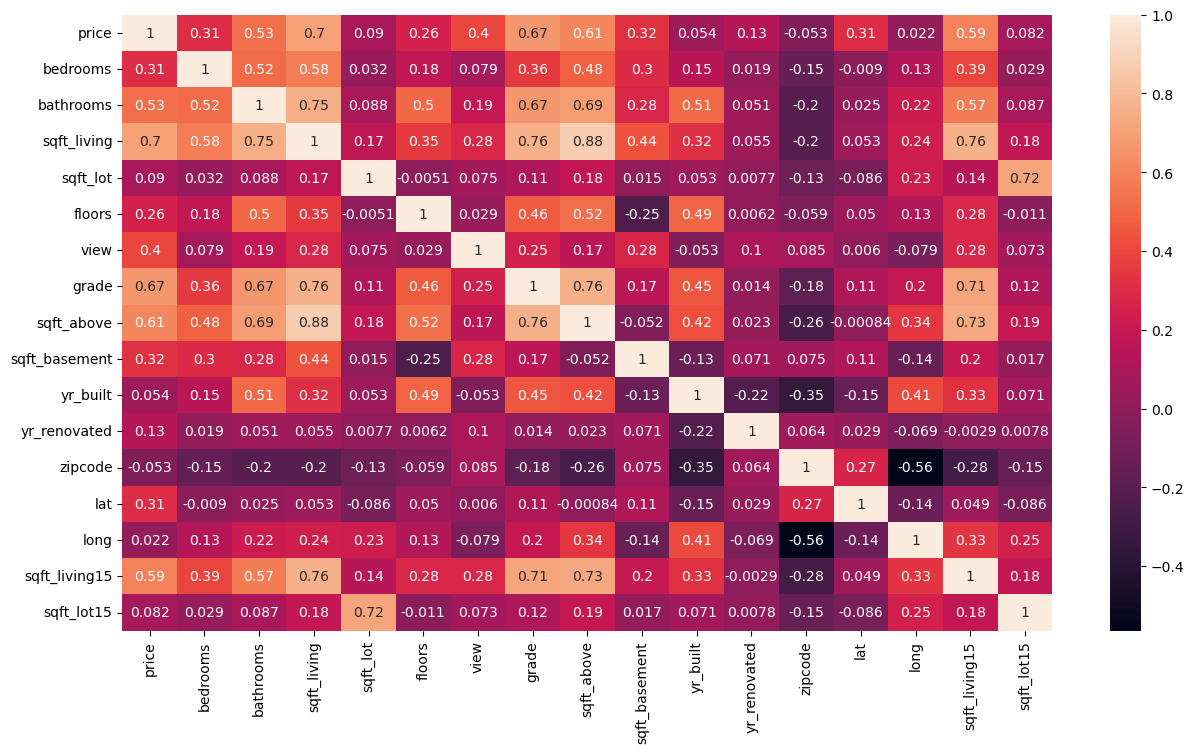

In [20]:
plt.figure(figsize=(15,8))
sns.heatmap(df.corr(numeric_only=True),annot=True)

array([[<Axes: title={'center': 'price'}>,
        <Axes: title={'center': 'bedrooms'}>,
        <Axes: title={'center': 'bathrooms'}>,
        <Axes: title={'center': 'sqft_living'}>],
       [<Axes: title={'center': 'sqft_lot'}>,
        <Axes: title={'center': 'floors'}>,
        <Axes: title={'center': 'view'}>,
        <Axes: title={'center': 'grade'}>],
       [<Axes: title={'center': 'sqft_above'}>,
        <Axes: title={'center': 'sqft_basement'}>,
        <Axes: title={'center': 'yr_built'}>,
        <Axes: title={'center': 'yr_renovated'}>],
       [<Axes: title={'center': 'zipcode'}>,
        <Axes: title={'center': 'lat'}>,
        <Axes: title={'center': 'long'}>,
        <Axes: title={'center': 'sqft_living15'}>],
       [<Axes: title={'center': 'sqft_lot15'}>, <Axes: >, <Axes: >,
        <Axes: >]], dtype=object)

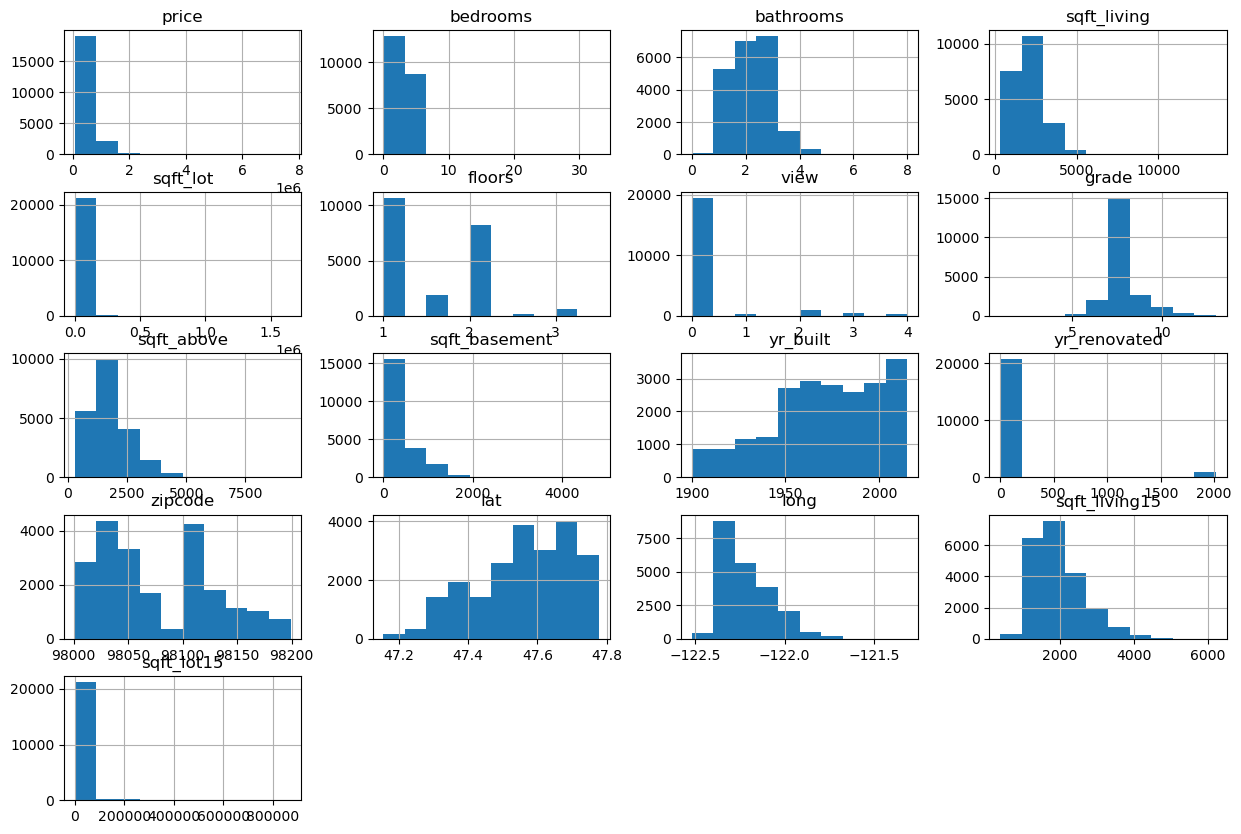

In [21]:
df.hist(figsize=(15,10))

In [22]:
df.skew(numeric_only=True)

price             4.023708
bedrooms          1.974363
bathrooms         0.511146
sqft_living       1.471467
sqft_lot         13.058691
floors            0.616340
view              3.396677
grade             0.771580
sqft_above        1.446740
sqft_basement     1.577731
yr_built         -0.469782
yr_renovated      4.551734
zipcode           0.405684
lat              -0.485183
long              0.885277
sqft_living15     1.108258
sqft_lot15        9.505818
dtype: float64

In [23]:
df.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,221900.0,3,1.00,1180,5650,1.0,N,0,Average,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,538000.0,3,2.25,2570,7242,2.0,N,0,Average,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,180000.0,2,1.00,770,10000,1.0,N,0,Average,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,604000.0,4,3.00,1960,5000,1.0,N,0,Very Good,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,510000.0,3,2.00,1680,8080,1.0,N,0,Average,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [24]:
df['condition'].value_counts()

condition
Average      14027
Good          5678
Very Good     1701
Fair           172
Poor            30
Name: count, dtype: int64

In [25]:
df=df.drop(['sqft_lot','yr_built','yr_renovated','sqft_lot15'],axis=1)

In [26]:
df

,price,bedrooms,bathrooms,sqft_living,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,zipcode,lat,long,sqft_living15
0,221900.0,3,1.00,1180,1.0,N,0,Average,7,1180,0,98178,47.5112,-122.257,1340
1,538000.0,3,2.25,2570,2.0,N,0,Average,7,2170,400,98125,47.7210,-122.319,1690
2,180000.0,2,1.00,770,1.0,N,0,Average,6,770,0,98028,47.7379,-122.233,2720
3,604000.0,4,3.00,1960,1.0,N,0,Very Good,7,1050,910,98136,47.5208,-122.393,1360
4,510000.0,3,2.00,1680,1.0,N,0,Average,8,1680,0,98074,47.6168,-122.045,1800
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,360000.0,3,2.50,1530,3.0,N,0,Average,8,1530,0,98103,47.6993,-122.346,1530
21609,400000.0,4,2.50,2310,2.0,N,0,Average,8,2310,0,98146,47.5107,-122.362,1830
21610,402101.0,2,0.75,1020,2.0,N,0,Average,7,1020,0,98144,47.5944,-122.299,1020
21611,400000.0,3,2.50,1600,2.0,N,0,Average,8,1600,0,98027,47.5345,-122.069,1410


In [27]:
df['view'].value_counts()

view
0    19485
2      963
3      509
1      332
4      319
Name: count, dtype: int64

In [28]:
condition_map={'Poor':0,'Fair':1,'Very Good':2,'Good':3,'Average':4}
df['condition']=df['condition'].map(condition_map)

In [29]:
df['waterfront']=df['waterfront'].map({'N':0,'Y':1})

In [30]:
df['zipcode'].value_counts().sum()

np.int64(21608)

In [31]:
df.head()

,price,bedrooms,bathrooms,sqft_living,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,zipcode,lat,long,sqft_living15
0,221900.0,3,1.00,1180,1.0,0,0,4,7,1180,0,98178,47.5112,-122.257,1340
1,538000.0,3,2.25,2570,2.0,0,0,4,7,2170,400,98125,47.7210,-122.319,1690
2,180000.0,2,1.00,770,1.0,0,0,4,6,770,0,98028,47.7379,-122.233,2720
3,604000.0,4,3.00,1960,1.0,0,0,2,7,1050,910,98136,47.5208,-122.393,1360
4,510000.0,3,2.00,1680,1.0,0,0,4,8,1680,0,98074,47.6168,-122.045,1800


In [32]:
from sklearn.model_selection import train_test_split

In [33]:
X=df.drop('price',axis=1)
y=df['price']

In [34]:
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42,test_size=0.3)

In [35]:
from sklearn.linear_model import LinearRegression

In [36]:
reg=LinearRegression()

In [37]:
reg.fit(X_train,y_train)

LinearRegression()

In [38]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

In [39]:
pred=reg.predict(X_test)
mae=mean_absolute_error(y_test,pred)
rmse=np.sqrt(mean_squared_error(y_test,pred))

In [40]:
mae

132852.48667166702

In [41]:
rmse

np.float64(217813.45651144572)

In [42]:
reg.score(X_test,y_test)

0.6838422059573389

In [43]:
reg.score(X_train,y_train)

0.6730212101582683

In [44]:
from sklearn.ensemble import RandomForestRegressor

In [45]:
forest=RandomForestRegressor(n_estimators=300,max_depth=15,random_state=42)

In [46]:
forest.fit(X_train,y_train)

RandomForestRegressor(max_depth=15, n_estimators=300, random_state=42)

In [47]:
forest.score(X_test,y_test) #What predicted

0.8810561606792133

In [48]:
forest.score(X_train,y_train) #What Learned

0.9715690684890601

In [53]:
import joblib
joblib.dump(forest,'House_price_model.pkl',compress=3)

['House_price_model.pkl']

In [54]:
X.columns.to_list()

['bedrooms',
 'bathrooms',
 'sqft_living',
 'floors',
 'waterfront',
 'view',
 'condition',
 'grade',
 'sqft_above',
 'sqft_basement',
 'zipcode',
 'lat',
 'long',
 'sqft_living15']

In [55]:
X_test

,bedrooms,bathrooms,sqft_living,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,zipcode,lat,long,sqft_living15
9399,4,3.00,3590,2.0,0,0,4,10,3590,0,98077,47.7557,-122.036,2790
18667,3,1.50,1310,1.0,0,0,3,7,1170,140,98103,47.6944,-122.333,1680
9996,3,1.50,1700,1.0,0,0,3,7,1100,600,98023,47.3209,-122.338,1700
10973,2,1.75,1280,1.0,0,0,4,7,1280,0,98033,47.6553,-122.190,1950
3043,2,1.00,990,1.0,0,0,4,6,990,0,98117,47.6939,-122.368,990
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7555,4,2.25,2000,2.0,0,1,3,7,2000,0,98023,47.3342,-122.340,2170
7685,3,2.75,2640,1.5,0,0,4,9,2260,380,98052,47.6491,-122.120,2640
9407,3,2.50,1690,2.0,0,0,4,7,1690,0,98038,47.3564,-122.016,1830
11926,3,2.50,2370,2.0,0,0,4,9,2370,0,98065,47.5427,-121.863,2660


In [97]:
y_test

9399      879000.0
18667     526500.0
9996      262000.0
10973     595000.0
3043      430000.0
           ...    
7555      320000.0
7685      698000.0
9407      305000.0
11926     522500.0
10446    3400000.0
Name: price, Length: 6483, dtype: float64

In [52]:
zip_info=df.groupby('zipcode')[['lat','long']].mean()

In [100]:
import joblib
joblib.dump(zip_info,'zip_info.pkl')

['zip_info.pkl']